In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

[['external',
  'vivit_decoder_only_no_rec_input_edt',
  10000,
      Finding  Se@FPpI=0.1  Se@FPpI=0.2  Se@FPpI=0.5  Se@FPpI=1.0  Se@FPpI=2.0  \
  0  aneurysm        0.505        0.624        0.683        0.713        0.772   
  1      Mean        0.505        0.624        0.683        0.713        0.772   
  
     Se@FPpI=4.0  Se@FPpI=8.0  
  0        0.822        0.832  
  1        0.822        0.832  ],
 ['external',
  'vivit_decoder_only_no_rec_input_edt',
  20000,
      Finding  Se@FPpI=0.1  Se@FPpI=0.2  Se@FPpI=0.5  Se@FPpI=1.0  Se@FPpI=2.0  \
  0  aneurysm        0.772        0.802        0.842        0.901        0.901   
  1      Mean        0.772        0.802        0.842        0.901        0.901   
  
     Se@FPpI=4.0  Se@FPpI=8.0  
  0        0.901        0.931  
  1        0.901        0.931  ],
 ['external',
  'vivit_decoder_only_no_rec_input_edt',
  30000,
      Finding  Se@FPpI=0.1  Se@FPpI=0.2  Se@FPpI=0.5  Se@FPpI=1.0  Se@FPpI=2.0  \
  0  aneurysm        0.683      

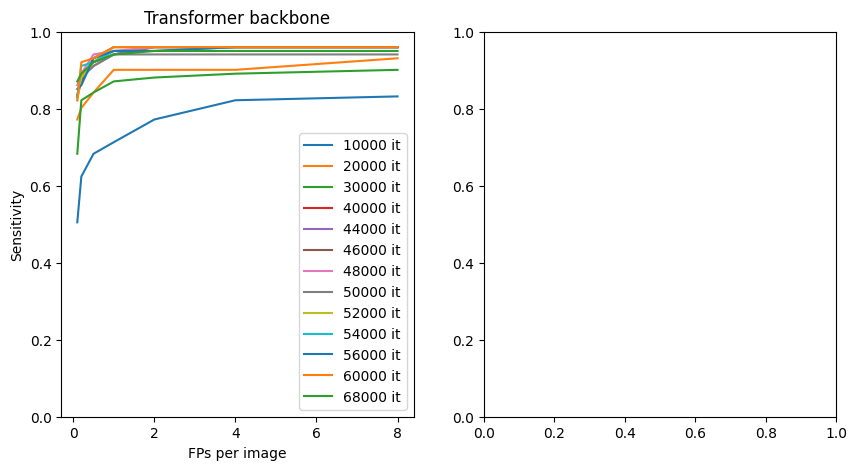

In [8]:
path_results = "../../results"
datasets = ["external"]
models = ["vivit_decoder_only_no_rec_input_edt", "vivit_decoder_only_no_rec_input_ed2t"]
names = ["Transformer backbone", "CNN backbone (4L)"]
iou = "0.2"
list_fields = []
for dataset in datasets:
    for model in models:
        path_base = Path(path_results) / dataset / model
        # get all subfolders matching pattern 
        results = sorted(list(path_base.glob(f"iou{iou}_*")))
        for result in results: 
            iterations = result.name.split("_")[-1]
            if iterations == "final":
                iterations = 68000
            else:
                iterations = int(iterations.replace("k",""))*1000
            csv_file = result / "froc.csv"
            df = pd.read_csv(csv_file)
            list_fields.append([dataset, model, iterations, df])



fig, ax = plt.subplots(1, 2, figsize=(10, 5))

examples_base = [l for l in list_fields if l[0] == "external"]

for i, model in enumerate(models):
    examples = [l for l in examples_base if l[1] == model]
    for example in examples: 
        x = [0.1, 0.2, 0.5, 1.0, 2.0, 4.0, 8.0]
        y = example[-1].iloc[0, 1:].values
        ax[i].plot(x, y, label= str(example[2]) + " it")
        ax[i].set_title(names[i])  
        ax[i].set_xlabel("FPs per image")
        ax[i].set_ylabel("Sensitivity")
        ax[i].legend()
        ax[i].set_ylim(0, 1)

In [22]:
df

NameError: name 'df' is not defined

In [13]:
list(path_base.glob("*"))

[PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.2_froc_40k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.3_froc_54k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.3_froc_48k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.2_froc_48k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/inference_50k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/inference_52k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/inference_30k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.2_froc_60k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.3_froc_final'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/iou0.2_froc_52k'),
 PosixPath('../../results/external/vivit_4l_decoder_only_no_rec_input_edt/